# Análisis Exploratorio de Datos (EDA)
Dataset crudo de descriptores atómicos — previo al preprocesamiento.

**Input:** `dataset_AA.csv`

In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import os

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.size'] = 11

PATH = 'dataset_AA.csv'
df = pd.read_csv(PATH)

output_dir = "EDA_output_AA"
os.makedirs(output_dir, exist_ok=True)

# Columnas de identificación
ID_COLS      = ['molecule', 'atom_id', 'atom_name']
TARGET_COLS  = ['atomtype', 'charge']

# Features categóricas
CAT_COLS  = ['tripos_type', 'element', 'neighbor_config', 'neighbor2_config']

# Features booleanas
BOOL_COLS = ['is_planar']

# Features numéricas continuas
NUM_COLS  = [
    'mass', 'coordination', 'n_dihedrals', 'avg_bond_len_A', 'avg_angle_deg',
    'C_count', 'H_count', 'O_count', 'N_count',
    'n_electroneg_neighbors', 'n_electroneg_neighbors2',
    'bonds_single', 'bonds_double', 'bonds_aromatic',
    'ring_size', 'formal_charge', 'degree_of_unsat', 'gasteiger_charge'
]
NUM_COLS = [c for c in NUM_COLS if c in df.columns]

print(f'Dataset: {df.shape[0]} átomos × {df.shape[1]} columnas')
print(f'Moléculas únicas: {df["molecule"].nunique()}')
print(f'Clases de atomtype: {df["atomtype"].nunique()}')

Dataset: 472 átomos × 16 columnas
Moléculas únicas: 7
Clases de atomtype: 20


## 1. Overview general

In [11]:
df.head(10)

,molecule,atom_id,atom_name,tripos_type,element,mass,coordination,avg_bond_len_A,avg_angle_deg,is_planar,C_count,H_count,O_count,N_count,atomtype,charge
0,22CLTSC_trans,1,H8,H8,H,1.008,1,1.0136,0.0000,False,0,0,0,1,HS14,0.331
1,22CLTSC_trans,2,N3,N3,N,14.007,3,1.1203,119.9394,True,1,2,0,0,NPri,-0.455
2,22CLTSC_trans,3,H7,H7,H,1.008,1,1.0125,0.0000,False,0,0,0,1,HS14,0.331
3,22CLTSC_trans,4,C8,C8,C,12.011,3,1.4659,120.0000,True,0,0,0,2,C,0.075
4,22CLTSC_trans,5,S1,S1,S,32.060,1,1.6980,0.0000,False,1,0,0,0,SDmso,-0.539
5,22CLTSC_trans,6,N2,N2,N,14.007,3,1.2497,119.9998,True,1,1,0,1,NOpt,0.113
6,22CLTSC_trans,7,H6,H6,H,1.008,1,1.0185,0.0000,False,0,0,0,1,HS14,0.193
7,22CLTSC_trans,8,N1,N1,N,14.007,2,1.3250,117.1305,False,1,0,0,1,NOpt,-0.256
8,22CLTSC_trans,9,C7,C7,C,12.011,3,1.2819,119.9997,True,1,1,0,1,C,-0.001
9,22CLTSC_trans,10,H5,H5,H,1.008,1,1.0975,0.0000,False,1,0,0,0,HC,0.158


In [12]:
# Valores nulos
nulls = df.isnull().sum()
nulls = nulls[nulls > 0]
if nulls.empty:
    print('✓ No hay valores nulos en el dataset.')
else:
    print('⚠ Columnas con valores nulos:')
    display(nulls.to_frame('nulos'))

✓ No hay valores nulos en el dataset.


In [13]:
# Estadísticas descriptivas — features numéricas
df[NUM_COLS].describe().T.round(3)

,count,mean,std,min,25%,50%,75%,max
mass,472.0,8.047,6.481,0.00,1.008,12.011,12.011,35.450
coordination,472.0,2.072,1.206,1.00,1.000,2.000,3.000,4.000
avg_bond_len_A,472.0,1.234,0.161,0.96,1.119,1.199,1.389,1.764
avg_angle_deg,472.0,57.629,56.998,0.00,0.000,106.209,109.470,179.652
C_count,472.0,1.246,0.710,0.00,1.000,1.000,2.000,4.000
H_count,472.0,0.428,0.698,0.00,0.000,0.000,1.000,3.000
O_count,472.0,0.269,0.511,0.00,0.000,0.000,0.000,2.000
N_count,472.0,0.112,0.323,0.00,0.000,0.000,0.000,2.000


## 2. Distribución de clases de atomtype (target de clasificación)

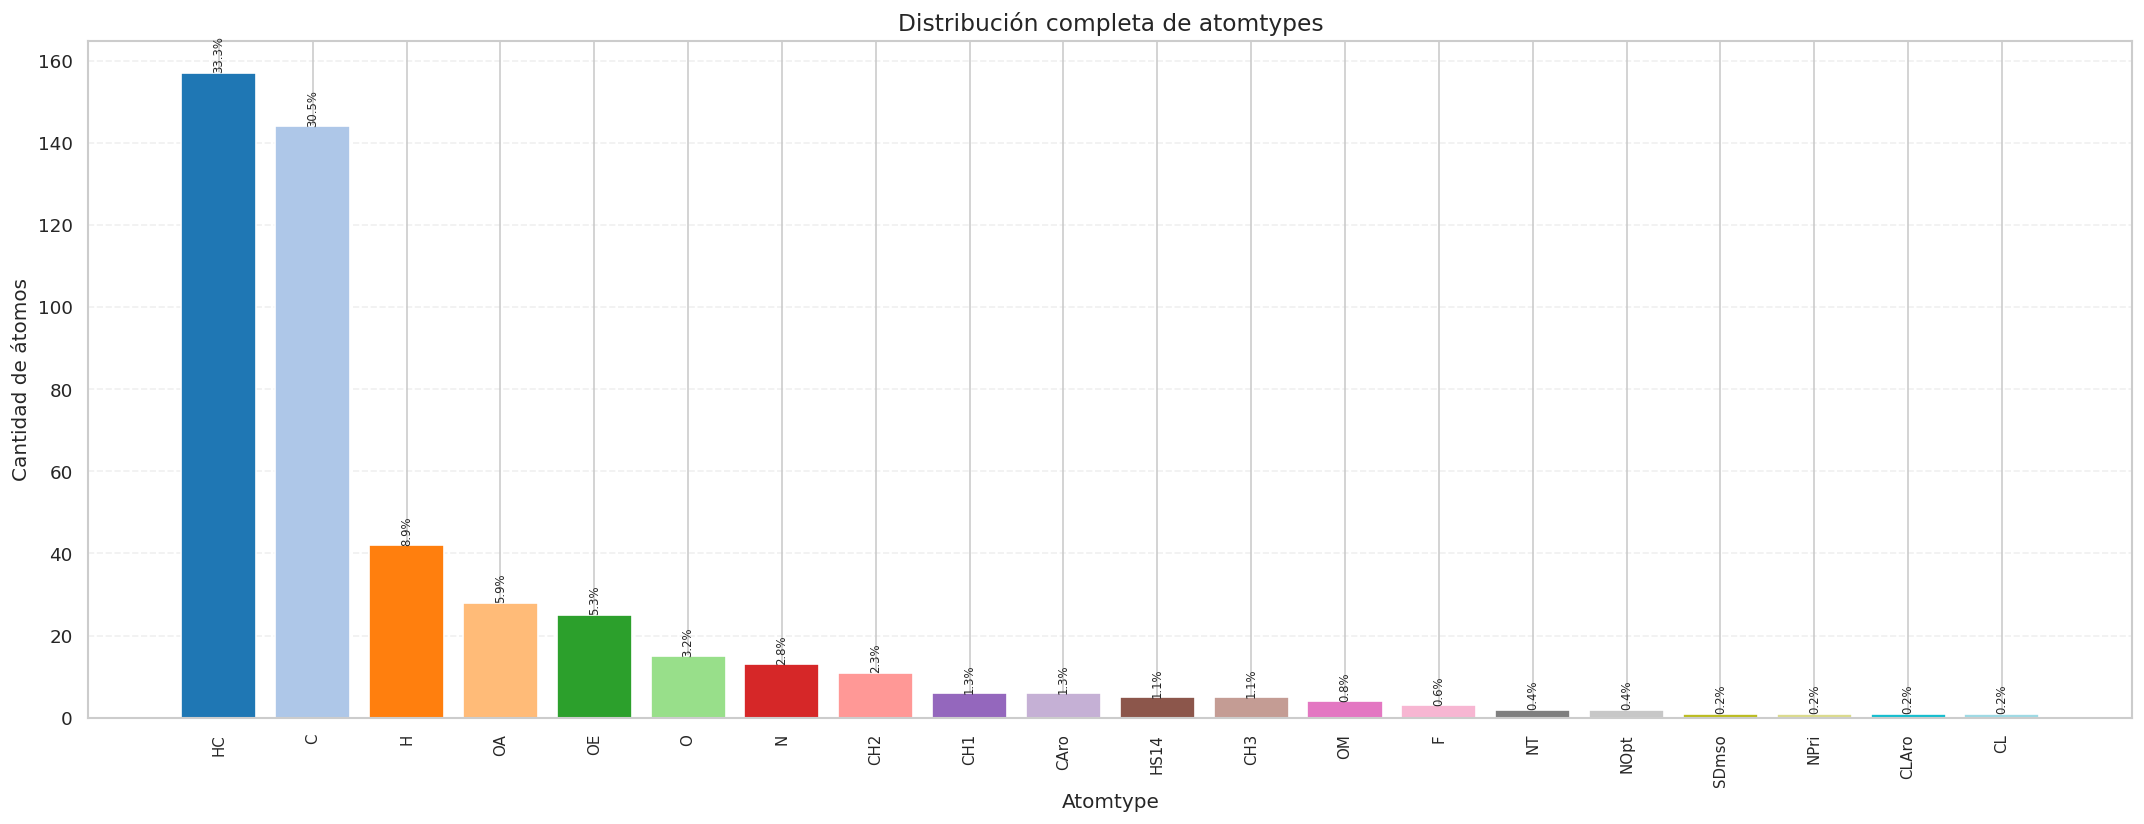

In [26]:
import os
import seaborn as sns
import matplotlib.pyplot as plt

# =========================
# DATA
# =========================
class_counts = df['atomtype'].value_counts().sort_values(ascending=False)
class_pct = (class_counts / len(df) * 100).round(2)

# =========================
# FIGURA
# =========================
plt.figure(figsize=(18, 7))

colors = sns.color_palette("tab20", len(class_counts))

bars = plt.bar(class_counts.index, class_counts.values, color=colors)

plt.title("Distribución completa de atomtypes", fontsize=14)
plt.xlabel("Atomtype")
plt.ylabel("Cantidad de átomos")

# rotación más agresiva para legibilidad
plt.xticks(rotation=90, ha='center', fontsize=9)

# =========================
# ANOTACIONES %
# =========================
for bar, pct in zip(bars, class_pct.values):
    plt.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height(),
        f"{pct:.1f}%",
        ha='center',
        va='bottom',
        fontsize=7,
        rotation=90
    )

plt.grid(axis='y', linestyle='--', alpha=0.3)

plt.tight_layout()

# =========================
# SAVE
# =========================
os.makedirs(output_dir, exist_ok=True)

plt.savefig(
    os.path.join(output_dir, "eda_atomtype_full.png"),
    dpi=300,
    bbox_inches='tight'
)

plt.show()

In [27]:
summary = pd.DataFrame({
    "count": class_counts,
    "percentage": class_pct
})

print("\n📊 Summary atomtype:")
print(summary)


📊 Summary atomtype:
          count  percentage
atomtype                   
HC          157       33.26
C           144       30.51
H            42        8.90
OA           28        5.93
OE           25        5.30
O            15        3.18
N            13        2.75
CH2          11        2.33
CH1           6        1.27
CAro          6        1.27
HS14          5        1.06
CH3           5        1.06
OM            4        0.85
F             3        0.64
NT            2        0.42
NOpt          2        0.42
SDmso         1        0.21
NPri          1        0.21
CLAro         1        0.21
CL            1        0.21


## 3. Distribución de charge (target de regresión)

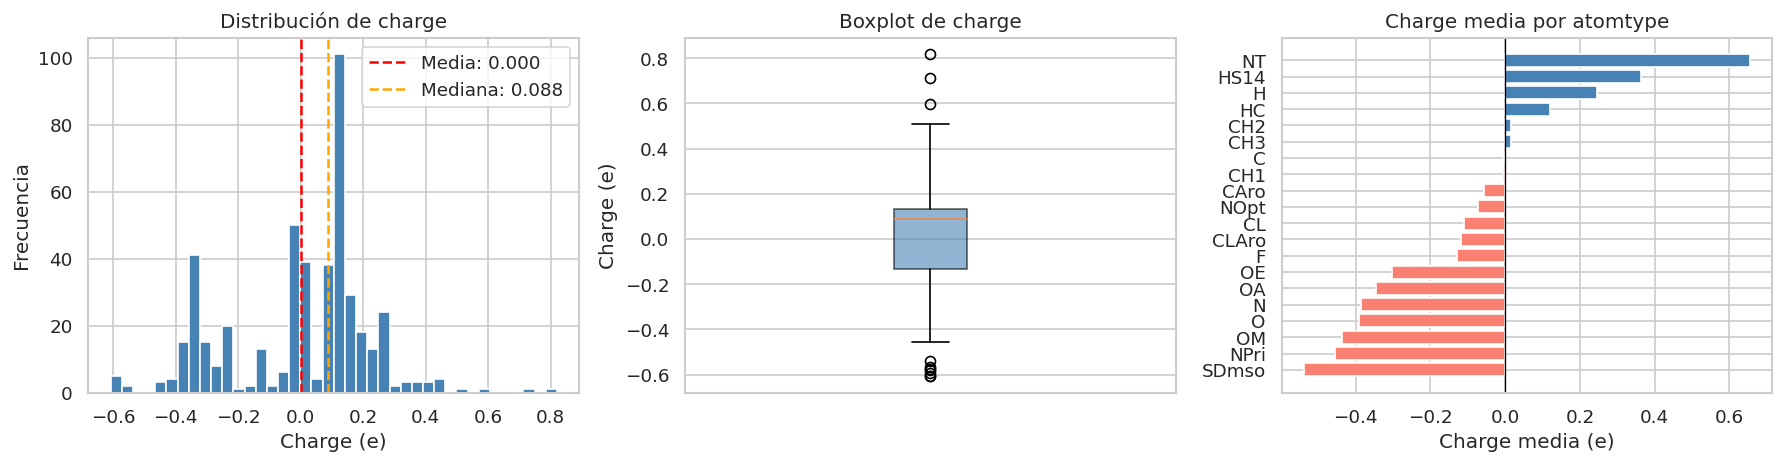

Media:    0.0000 e
Std:      0.2235 e
Min:      -0.6080 e
Max:      0.8200 e
Skewness: -0.3742
✓ Distribución aproximadamente simétrica.


In [15]:
charge = df['charge']

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Histograma
axes[0].hist(charge, bins=40, color='steelblue', edgecolor='white')
axes[0].axvline(charge.mean(), color='red', linestyle='--', label=f'Media: {charge.mean():.3f}')
axes[0].axvline(charge.median(), color='orange', linestyle='--', label=f'Mediana: {charge.median():.3f}')
axes[0].set_xlabel('Charge (e)')
axes[0].set_ylabel('Frecuencia')
axes[0].set_title('Distribución de charge')
axes[0].legend()

# Boxplot
axes[1].boxplot(charge, patch_artist=True,
                boxprops=dict(facecolor='steelblue', alpha=0.6))
axes[1].set_title('Boxplot de charge')
axes[1].set_ylabel('Charge (e)')
axes[1].set_xticks([])

# Charge media por atomtype
charge_by_type = df.groupby('atomtype')['charge'].mean().sort_values()
colors_bar = ['salmon' if v < 0 else 'steelblue' for v in charge_by_type.values]
axes[2].barh(charge_by_type.index, charge_by_type.values, color=colors_bar)
axes[2].axvline(0, color='black', linewidth=0.8)
axes[2].set_xlabel('Charge media (e)')
axes[2].set_title('Charge media por atomtype')

plt.tight_layout()
plt.savefig(os.path.join(output_dir, "eda_charge_distribution.png"), bbox_inches='tight')
plt.show()

print(f'Media:    {charge.mean():.4f} e')
print(f'Std:      {charge.std():.4f} e')
print(f'Min:      {charge.min():.4f} e')
print(f'Max:      {charge.max():.4f} e')
print(f'Skewness: {charge.skew():.4f}')
if abs(charge.skew()) > 1:
    print('⚠ Distribución sesgada — considerar normalización del target.')
else:
    print('✓ Distribución aproximadamente simétrica.')

## 4. Variables categóricas — cardinalidad y frecuencia



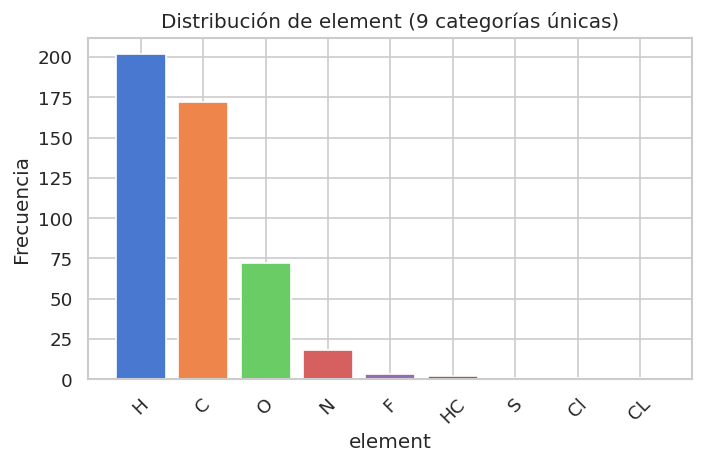

In [16]:
for col in ['tripos_type', 'element']:
    if col not in df.columns:
        continue
    counts = df[col].value_counts()
    fig, ax = plt.subplots(figsize=(max(6, len(counts)*0.6), 4))
    ax.bar(counts.index, counts.values, color=sns.color_palette('muted', len(counts)))
    ax.set_title(f'Distribución de {col} ({len(counts)} categorías únicas)')
    ax.set_xlabel(col)
    ax.set_ylabel('Frecuencia')
    ax.tick_params(axis='x', rotation=45)
    plt.tight_layout()
    plt.savefig(os.path.join(output_dir,f'eda_{col}_distribution.png'), bbox_inches='tight')
    plt.show()

# Cardinalidad de neighbor_config y neighbor2_config
for col in ['neighbor_config', 'neighbor2_config']:
    if col in df.columns:
        n_unique = df[col].nunique()
        print(f'{col}: {n_unique} valores únicos — top 10:')
        print(df[col].value_counts().head(10).to_string())
        print()

## 5. Variables booleanas

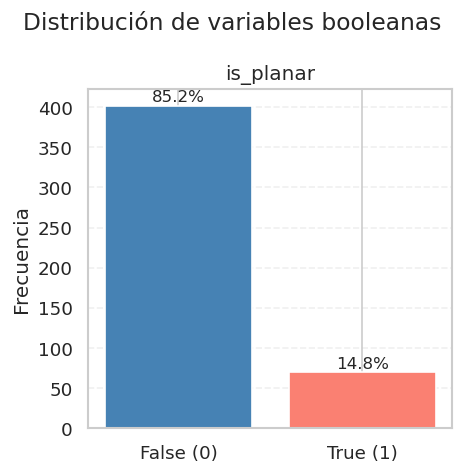

In [19]:
import os
import matplotlib.pyplot as plt

n = len(BOOL_COLS)

fig, axes = plt.subplots(1, n, figsize=(4*n, 4))

# 🔥 caso especial: una sola columna
if n == 1:
    axes = [axes]

for ax, col in zip(axes, BOOL_COLS):
    
    # ordenar explícitamente 0/1 si existen
    counts = df[col].value_counts().reindex([0, 1], fill_value=0)

    total = counts.sum()

    bars = ax.bar(
        ["False (0)", "True (1)"],
        counts.values,
        color=["steelblue", "salmon"]
    )

    ax.set_title(col, fontsize=12)
    ax.set_ylabel("Frecuencia")

    # 🔥 etiquetas de porcentaje sobre cada barra
    for bar, v in zip(bars, counts.values):
        pct = (v / total) * 100 if total > 0 else 0

        ax.text(
            bar.get_x() + bar.get_width()/2,
            bar.get_height() + total * 0.01,
            f"{pct:.1f}%",
            ha="center",
            fontsize=10
        )

    ax.grid(axis="y", linestyle="--", alpha=0.3)

plt.suptitle("Distribución de variables booleanas", fontsize=14)

plt.tight_layout()

# guardar de forma segura
os.makedirs(output_dir, exist_ok=True)

plt.savefig(
    os.path.join(output_dir, "eda_boolean_features.png"),
    bbox_inches="tight",
    dpi=300
)

plt.show()

## 6. Distribución de features numéricas

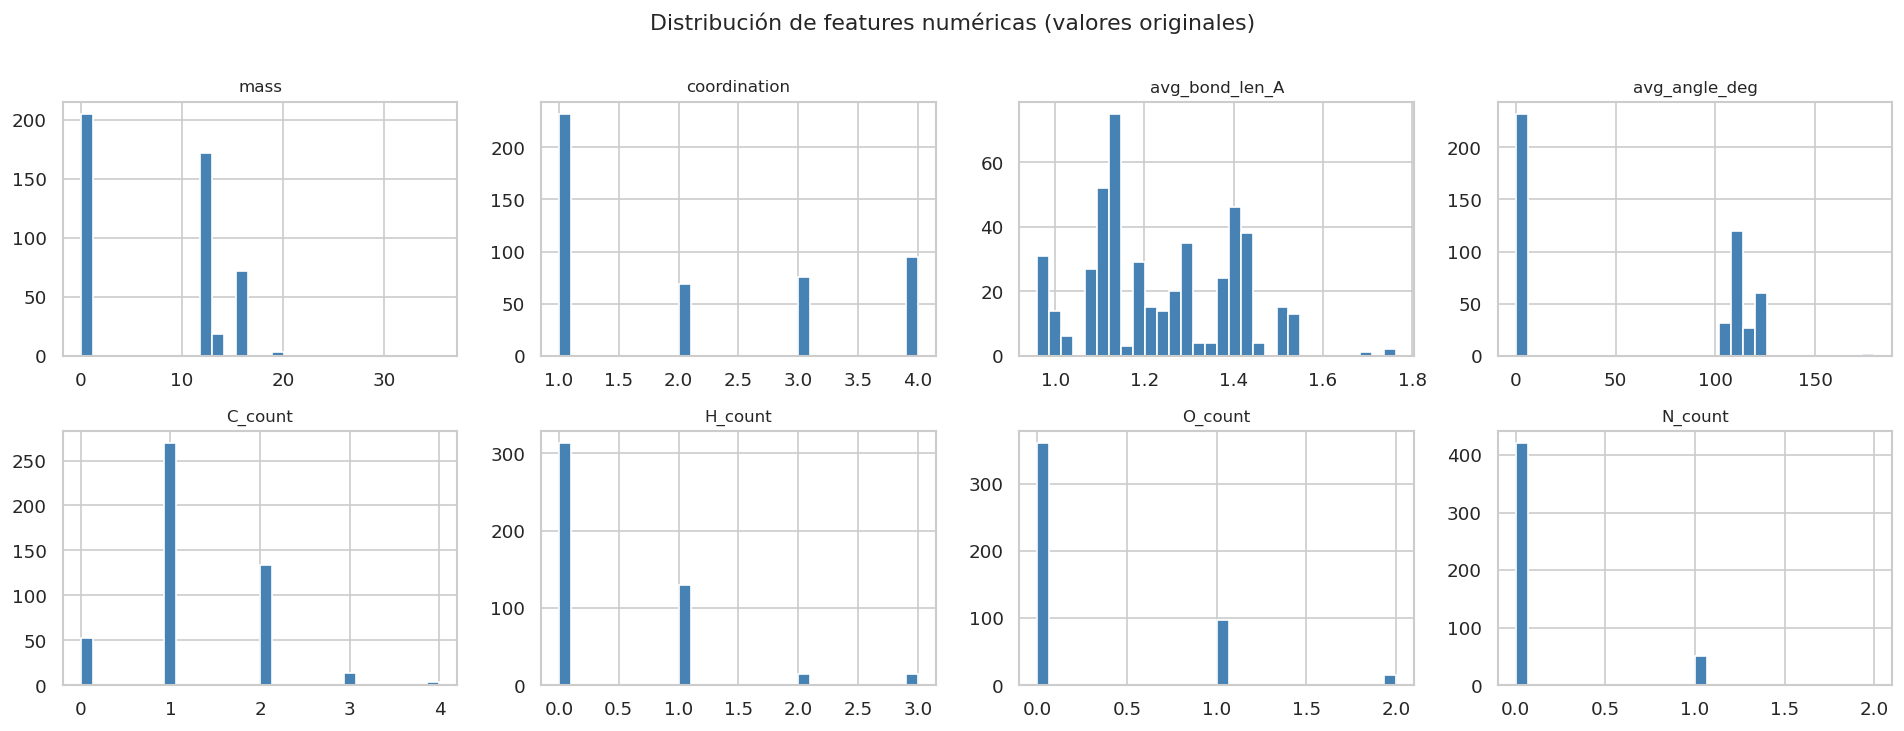

In [20]:
n_cols = 4
n_rows = int(np.ceil(len(NUM_COLS) / n_cols))
fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, n_rows * 3))
axes = axes.flatten()

for i, col in enumerate(NUM_COLS):
    axes[i].hist(df[col].dropna(), bins=30, color='steelblue', edgecolor='white')
    axes[i].set_title(col, fontsize=10)
    axes[i].set_xlabel('')

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Distribución de features numéricas (valores originales)', y=1.01)
plt.tight_layout()
plt.savefig(os.path.join(output_dir, "eda_numeric_histograms.png"), bbox_inches='tight')
plt.show()

## 7. Detección de outliers

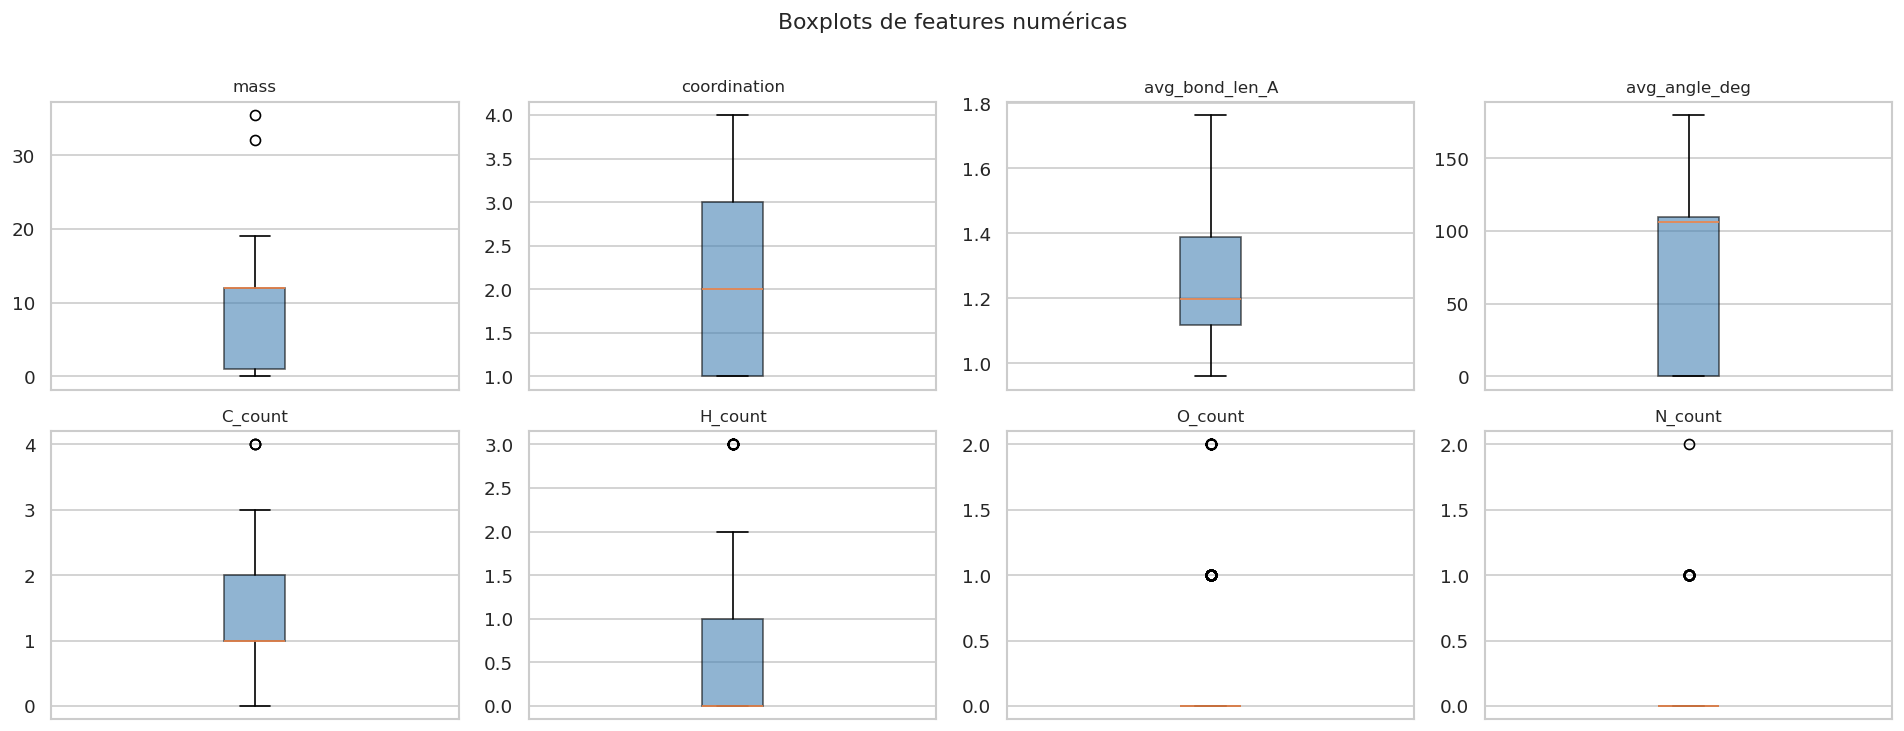

=== Outliers por IQR ===
  mass: 2 outliers (0.4%)
  C_count: 3 outliers (0.6%)
  H_count: 14 outliers (3.0%)
  O_count: 112 outliers (23.7%)
  N_count: 52 outliers (11.0%)


In [21]:
fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, n_rows * 3))
axes = axes.flatten()

for i, col in enumerate(NUM_COLS):
    axes[i].boxplot(df[col].dropna(), patch_artist=True,
                    boxprops=dict(facecolor='steelblue', alpha=0.6))
    axes[i].set_title(col, fontsize=10)
    axes[i].set_xticks([])

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Boxplots de features numéricas', y=1.01)
plt.tight_layout()
plt.savefig(os.path.join(output_dir, "eda_outliers_boxplots.png"), bbox_inches='tight')
plt.show()

print('=== Outliers por IQR ===')
for col in NUM_COLS:
    Q1, Q3 = df[col].quantile(0.25), df[col].quantile(0.75)
    IQR = Q3 - Q1
    n_out = ((df[col] < Q1 - 1.5*IQR) | (df[col] > Q3 + 1.5*IQR)).sum()
    if n_out > 0:
        print(f'  {col}: {n_out} outliers ({n_out/len(df)*100:.1f}%)')

## 8. Matriz de correlación entre features numéricas

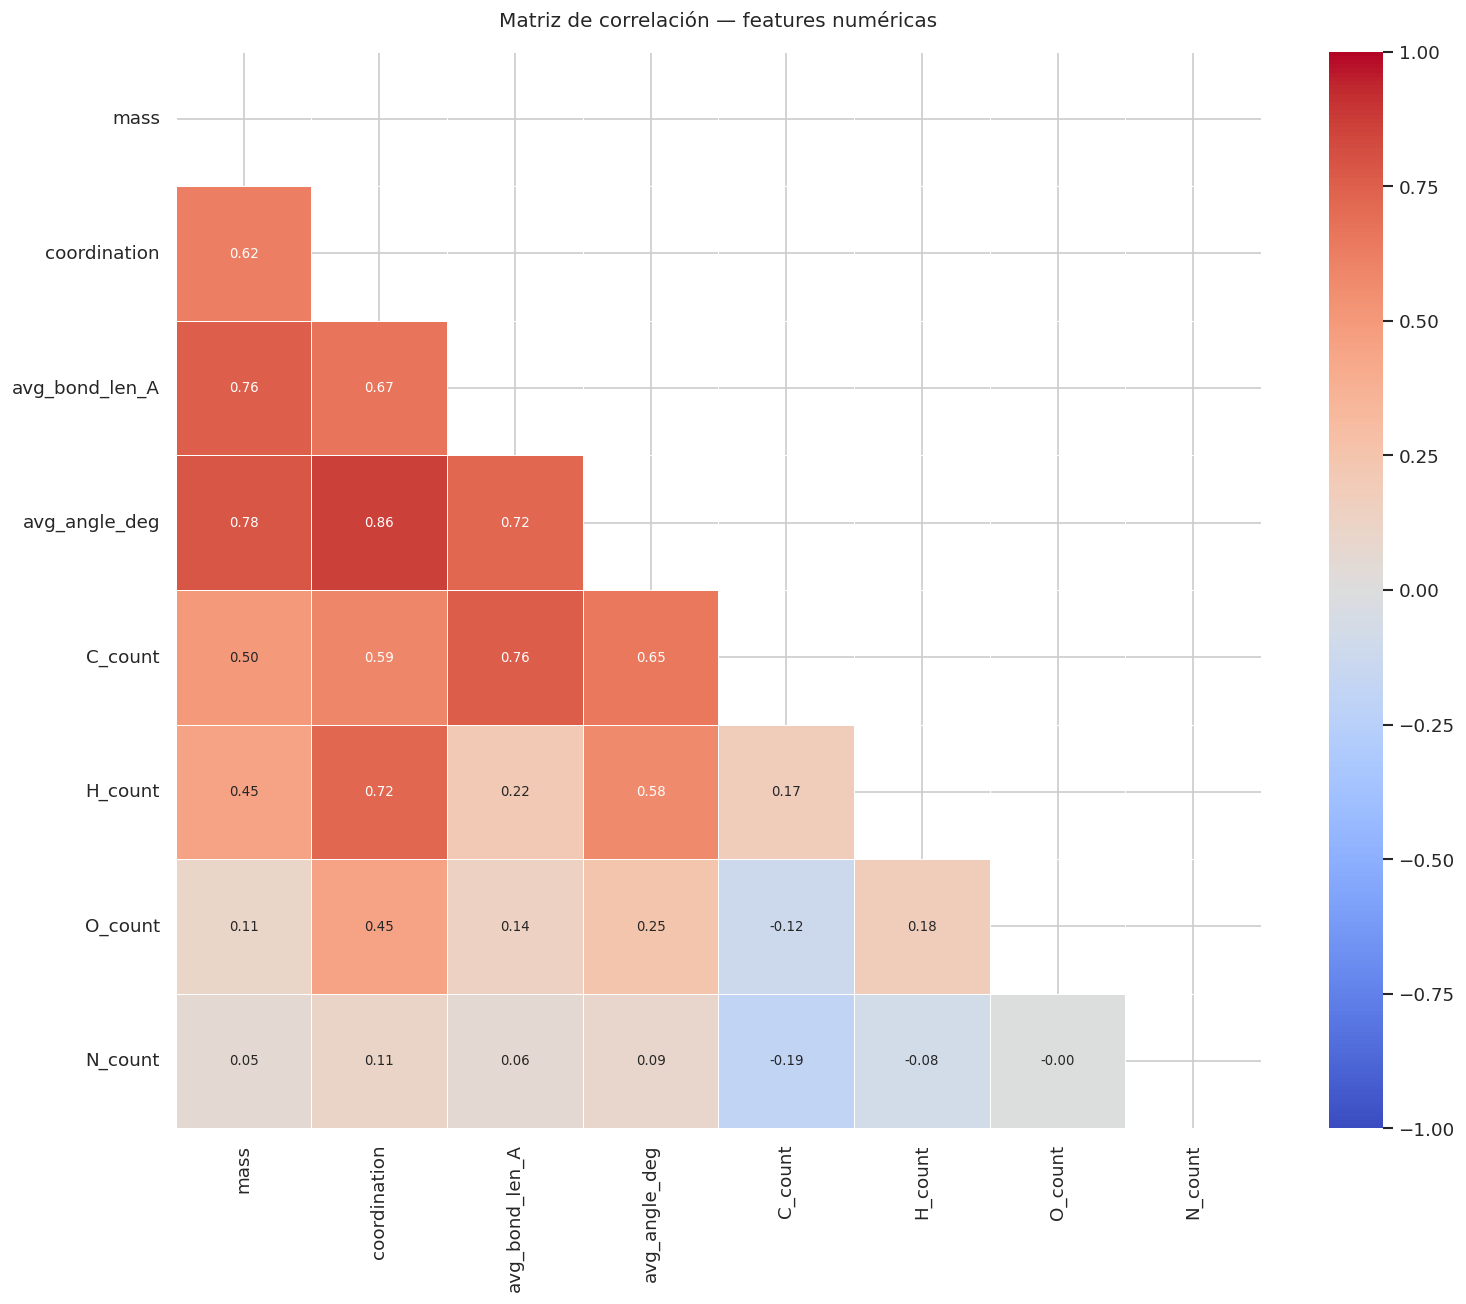

=== Pares con correlación alta (|r| > 0.8) ===
  coordination ↔ avg_angle_deg: r = 0.861
⚠ Evaluar eliminación de features redundantes.


In [22]:
corr = df[NUM_COLS].corr()

fig, ax = plt.subplots(figsize=(13, 11))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, vmin=-1, vmax=1, linewidths=0.5, ax=ax,
            annot_kws={'size': 8})
ax.set_title('Matriz de correlación — features numéricas', pad=15)
plt.tight_layout()
plt.savefig(os.path.join(output_dir,'eda_correlation_matrix.png'), bbox_inches='tight')
plt.show()

high_corr = []
for i in range(len(corr.columns)):
    for j in range(i + 1, len(corr.columns)):
        r = corr.iloc[i, j]
        if abs(r) > 0.8:
            high_corr.append((corr.columns[i], corr.columns[j], round(r, 3)))

print('=== Pares con correlación alta (|r| > 0.8) ===')
if high_corr:
    for a, b, r in sorted(high_corr, key=lambda x: -abs(x[2])):
        print(f'  {a} ↔ {b}: r = {r}')
    print('⚠ Evaluar eliminación de features redundantes.')
else:
    print('✓ No hay pares con correlación > 0.8.')

## 9. Features numéricas por atomtype

/tmp/ipykernel_668135/756137447.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='atomtype', y=feat, ax=axes[i], palette='muted')
/tmp/ipykernel_668135/756137447.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='atomtype', y=feat, ax=axes[i], palette='muted')


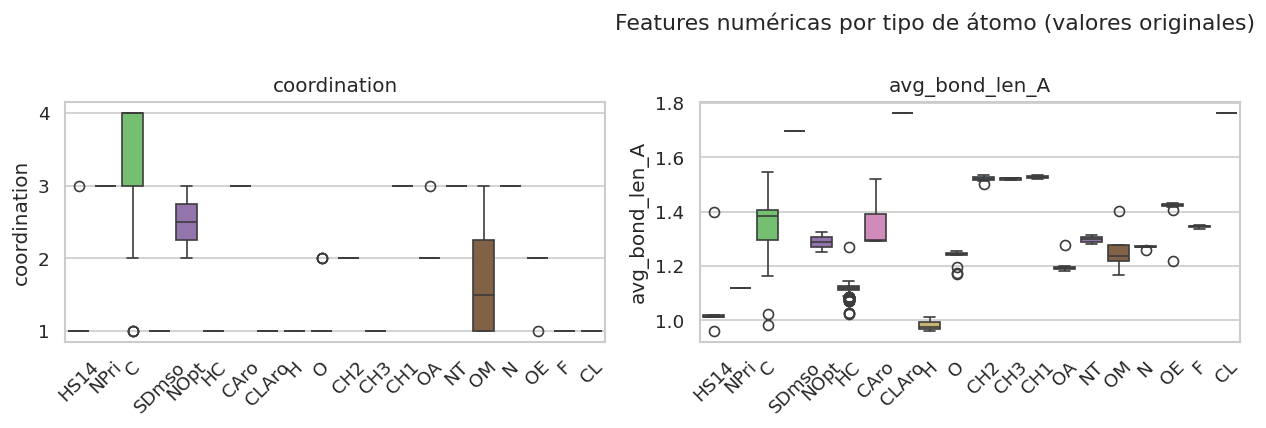

In [23]:
key_features = ['coordination', 'bonds_aromatic', 'bonds_double', 'bonds_single',
                'gasteiger_charge', 'degree_of_unsat', 'n_electroneg_neighbors',
                'is_in_ring', 'ring_size', 'avg_bond_len_A']
key_features = [c for c in key_features if c in df.columns]

n_cols = 3
n_rows = int(np.ceil(len(key_features) / n_cols))
fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, n_rows * 3.5))
axes = axes.flatten()

for i, feat in enumerate(key_features):
    sns.boxplot(data=df, x='atomtype', y=feat, ax=axes[i], palette='muted')
    axes[i].set_title(feat)
    axes[i].set_xlabel('')
    axes[i].tick_params(axis='x', rotation=45)

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Features numéricas por tipo de átomo (valores originales)', y=1.01)
plt.tight_layout()
plt.savefig(os.path.join(output_dir, "eda_features_by_atomtype.png"), bbox_inches='tight')
plt.show()

## 10. Resumen y decisiones para el preprocesamiento

In [24]:
print('=' * 55)
print('RESUMEN EDA')
print('=' * 55)
print(f'  Moléculas únicas:        {df["molecule"].nunique()}')
print(f'  Total de átomos:         {len(df)}')
print(f'  Features totales:        {df.shape[1] - len(ID_COLS) - len(TARGET_COLS)}')
print(f'  Clases de atomtype:      {df["atomtype"].nunique()}')
print(f'  Rango de charge:         [{df["charge"].min():.3f}, {df["charge"].max():.3f}]')
print(f'  Valores nulos totales:   {df.isnull().sum().sum()}')
print()

ratio = df['atomtype'].value_counts().max() / df['atomtype'].value_counts().min()

print('DECISIONES SUGERIDAS PARA EL PREPROCESAMIENTO:')
print()
if ratio > 5:
    print(f'  ⚠ Desbalance de clases ({ratio:.1f}x) — usar class_weight="balanced" al entrenar.')
else:
    print(f'  ✓ Clases balanceadas (ratio {ratio:.1f}x) — no requiere acción.')

if abs(df['charge'].skew()) > 1:
    print(f'  ⚠ Charge sesgada (skew={df["charge"].skew():.2f}) — evaluar escalado del target.')
else:
    print(f'  ✓ Charge simétrica (skew={df["charge"].skew():.2f}) — no requiere transformación.')

if high_corr:
    print(f'  ⚠ {len(high_corr)} par(es) con alta correlación — evaluar eliminación.')
else:
    print('  ✓ Sin multicolinealidad problemática.')

for col in ['neighbor_config', 'neighbor2_config']:
    if col in df.columns:
        n_u = df[col].nunique()
        print(f'  → {col}: {n_u} valores únicos — aplicar hash en preprocesamiento.')

RESUMEN EDA
  Moléculas únicas:        7
  Total de átomos:         472
  Features totales:        11
  Clases de atomtype:      20
  Rango de charge:         [-0.608, 0.820]
  Valores nulos totales:   0

DECISIONES SUGERIDAS PARA EL PREPROCESAMIENTO:

  ⚠ Desbalance de clases (157.0x) — usar class_weight="balanced" al entrenar.
  ✓ Charge simétrica (skew=-0.37) — no requiere transformación.
  ⚠ 1 par(es) con alta correlación — evaluar eliminación.
